In [2]:
from pathlib import Path
from datetime import datetime
import xarray as xr
import numpy as np
import pandas as pd
from gfatpy.lidar.preprocessing import preprocess
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

%matplotlib inline

In [165]:
nebula_path = Path( r"c:\Users\Usuario\Downloads\datos\20210611_granada_rpg-fmcw-94.nc")
siroco_path = Path(r"c:\Users\Usuario\Downloads\datos\20210611_granada_finf_g200_halo-doppler-lidar_co.nc")

nebula_path.exists(), siroco_path.exists()

(True, True)

In [169]:
nb = xr.open_dataset(nebula_path)   
sc = xr.open_dataset(siroco_path)

time = sc.time
day = sc.attrs['day'].astype(int)
month = sc.attrs['month'].astype(int)
year = sc.attrs['year'].astype(int)
date = datetime(year, month, day)
datetime_ = date + pd.to_timedelta(time, unit='h')
#replace sc.time with datetime
sc = sc.assign_coords(time=datetime_)

#Choose period and range
start = datetime(2021,6,11, 10, 0, 0)
end = datetime(2021,6,11, 13, 0, 0)
min_range = 0
max_range = 1500
sc = sc.sel(time=slice(start, end), range=slice(min_range, max_range))
nb = nb.sel(time=slice(start, end), range=slice(min_range, max_range))

#resample to 1 minutes
nb = nb.resample(time='1min').mean()
sc = sc.resample(time='1min').mean()

#Match sc range resolution to nb range resolution
sc = sc.interp(range=nb.range, method='nearest')


In [170]:
# np.diff(sc.range),sc.range.shape,
np.diff(nb.range), nb.range.shape


(array([29.811768, 29.811783, 29.811768, 29.811768, 29.811768, 29.811768,
        29.811768, 29.811798, 29.811768, 29.811768, 29.811768, 29.811768,
        29.811768, 29.811768, 29.811768, 29.811768, 29.811768, 29.811768,
        29.811768, 29.811829, 29.811768, 29.811768, 29.811768, 29.811768,
        29.811768, 29.811768, 29.811768, 29.811768, 29.811768, 29.811768,
        29.811768, 29.811768, 29.811768, 29.811768, 29.811768, 29.811768,
        29.811768, 29.811768, 29.811768, 29.811768, 29.811768, 29.811768,
        29.811768, 29.81189 , 29.811768, 29.811768], dtype=float32),
 (47,))

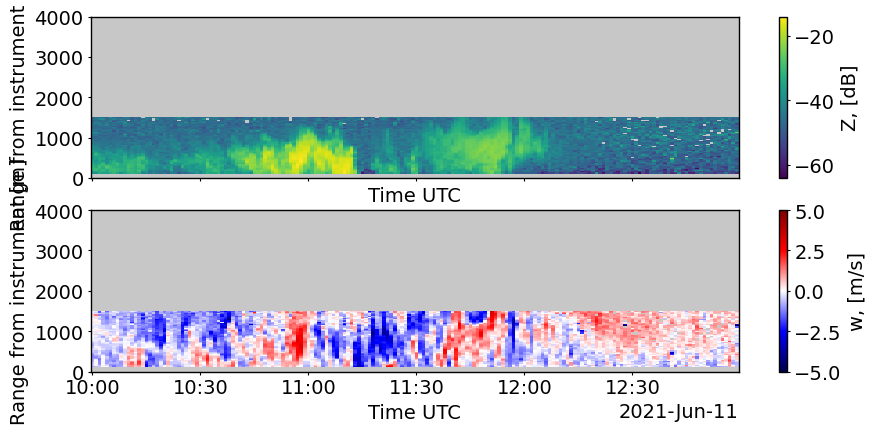

In [171]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5),sharex=True)
q1 = nb['Zh'].plot(y='range', ax=ax[0],cmap='viridis', add_colorbar=False)
#get colorbar handle from q1
cbar = plt.colorbar(q1, ax=ax[0])
cbar.set_label('Z, [dB]')
ax[0].set_ylim(0, 4000)

q2 = nb['v'].plot(y='range', ax=ax[1], cmap='seismic', vmin=-5, vmax=5, add_colorbar=False)
cbar = plt.colorbar(q2, ax=ax[1])
cbar.set_label('w, [m/s]')
ax[1].set_ylim(0, 4000)


plt.show()

(0.0, 4000.0)

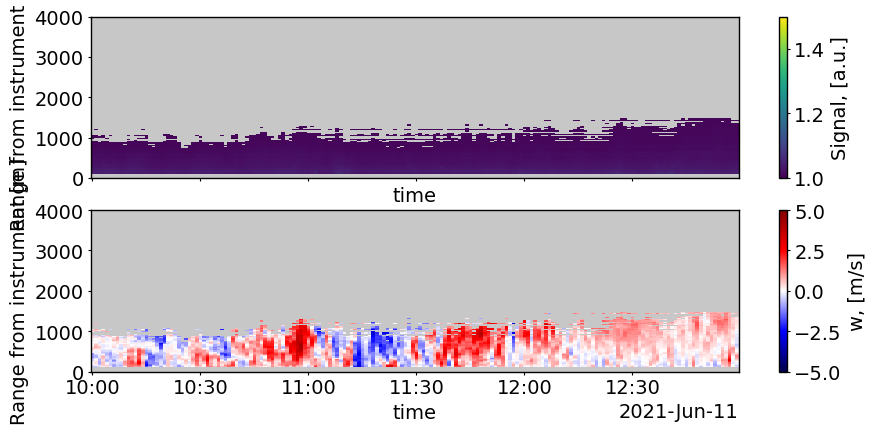

In [172]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5),sharex=True)
q1 = sc['signal'].where(sc["signal"] > 1.006).plot(y='range', ax=ax[0],cmap='viridis', vmin=1, vmax=1.5, add_colorbar=False)
#get colorbar handle from q1
cbar = plt.colorbar(q1, ax=ax[0])
cbar.set_label('Signal, [a.u.]')
ax[0].set_ylim(0, 4000)

q2 = sc['v_raw'].where(sc["signal"] > 1.006).plot(y='range', ax=ax[1], cmap='seismic', vmin=-5, vmax=5, add_colorbar=False)
cbar = plt.colorbar(q2, ax=ax[1])
cbar.set_label('w, [m/s]')
ax[1].set_ylim(0, 4000)


(0.0, 4000.0)

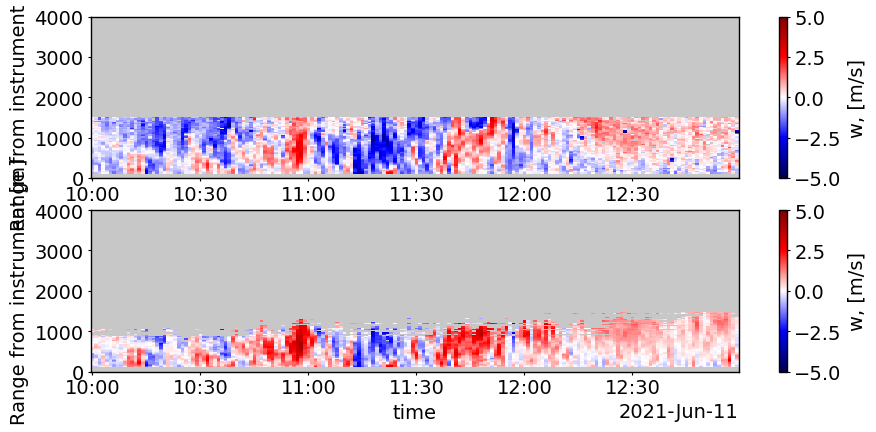

In [173]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5),sharex=False)
q1 = nb['v'].plot(y='range', ax=ax[0], cmap='seismic', vmin=-5, vmax=5, add_colorbar=False)
cbar = plt.colorbar(q1, ax=ax[0])
cbar.set_label('w, [m/s]')
ax[0].set_ylim(0, 4000)

q2 = sc['v_raw'].where(sc["signal"] > 1.006).plot(y='range', ax=ax[1], cmap='seismic', vmin=-5, vmax=5, add_colorbar=False)
cbar = plt.colorbar(q2, ax=ax[1])
cbar.set_label('w, [m/s]')
ax[1].set_ylim(0, 4000)


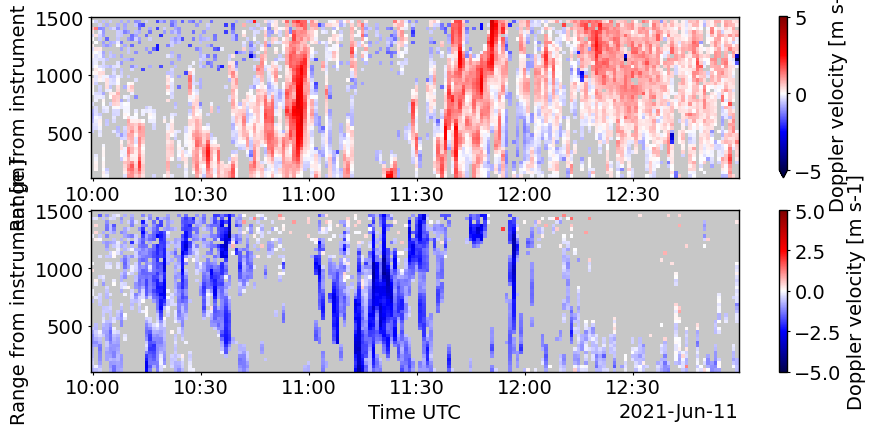

In [174]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5),sharex=False)
nb['v'].where(sc["v_raw"] > 0.).plot(y='range', cmap='seismic', vmin=-5, vmax=5,ax=ax[0])
nb['v'].where(sc["v_raw"] < 0.).plot(y='range', cmap='seismic', vmin=-5, vmax=5,ax=ax[1])

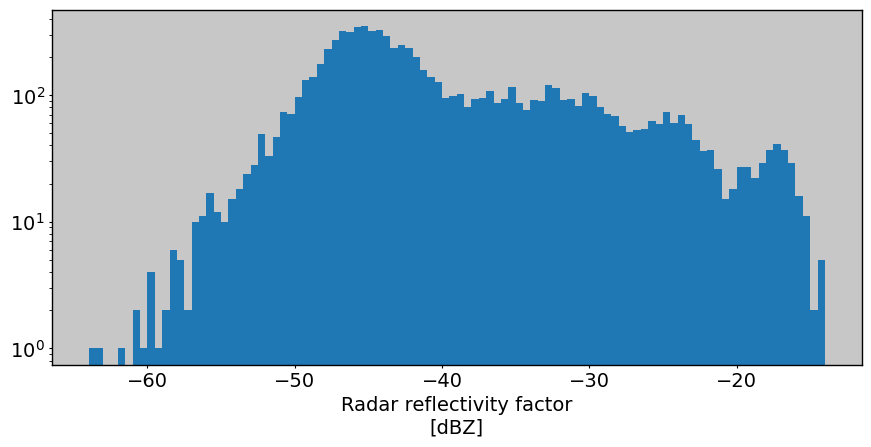

In [175]:
#plot histogram of nb['Zh']
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
nb['Zh'].plot.hist(ax=ax, bins=100, log=True)
plt.show()


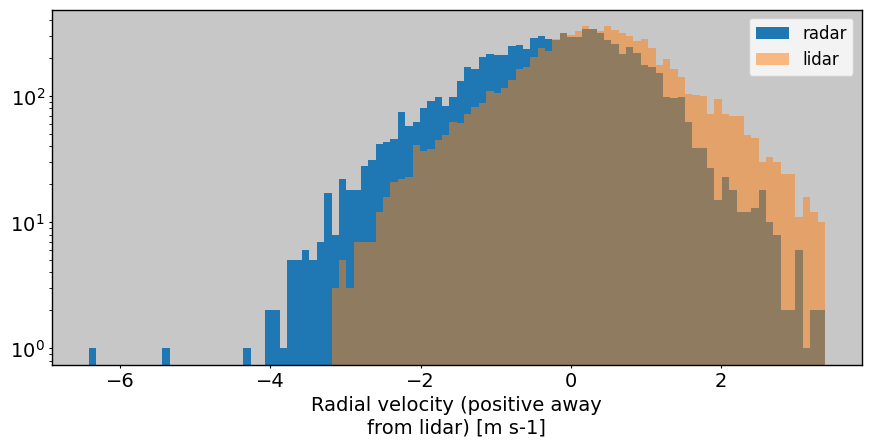

In [176]:
#plot histogram of nb['Zh']
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
hist = nb['v'].plot.hist(ax=ax, bins=100, log=True, alpha=1., label='radar')
#use the same bins for sc['v_raw']
sc['v_raw'].plot.hist(ax=ax, bins=hist[1], log=True, alpha=0.5, label='lidar')
plt.legend()

In [178]:
positive_flag = np.logical_and(nb['v'] > 0., sc["v_raw"] > 0.)
negative_flag = np.logical_and(nb['v'] < 0., sc["v_raw"] < 0.)
terminal_v_positive = nb['v'].where(positive_flag) - sc['v_raw'].where(positive_flag)
terminal_v_negative = nb['v'].where(negative_flag) - sc['v_raw'].where(negative_flag)
large_v = sc['v_raw'].where(sc["v_raw"] > 4.)
low_v = sc['v_raw'].where(sc["v_raw"] < -4.)

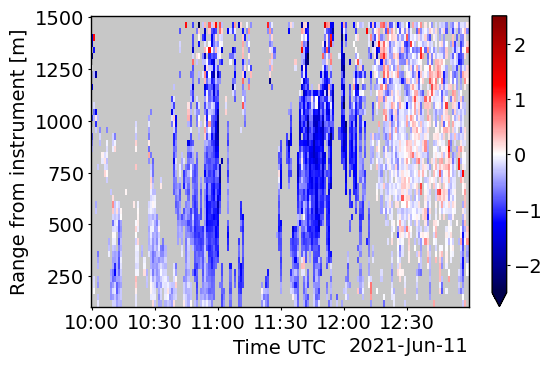

In [179]:
terminal_v_positive.plot(y='range', cmap='seismic', vmin=-2.5, vmax=2.5)


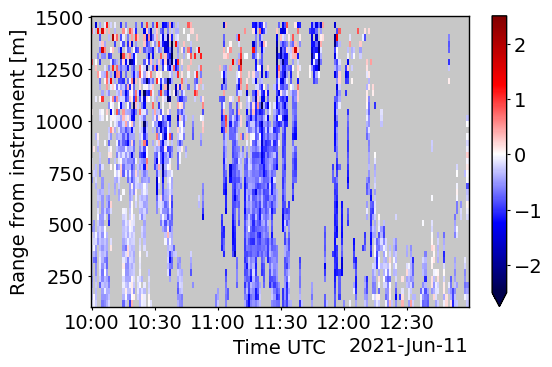

In [180]:
terminal_v_negative.plot(y='range', cmap='seismic', vmin=-2.5, vmax=2.5)


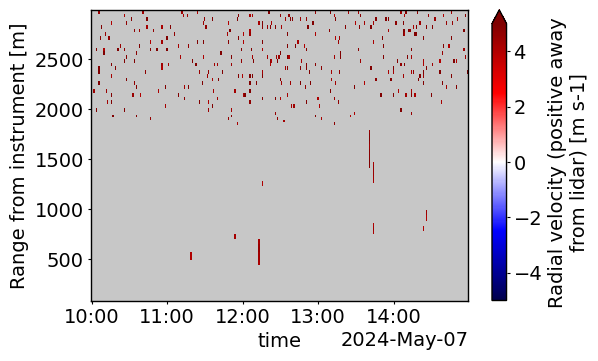

In [123]:
large_v.plot(y='range', cmap='seismic', vmin=-5, vmax=5)

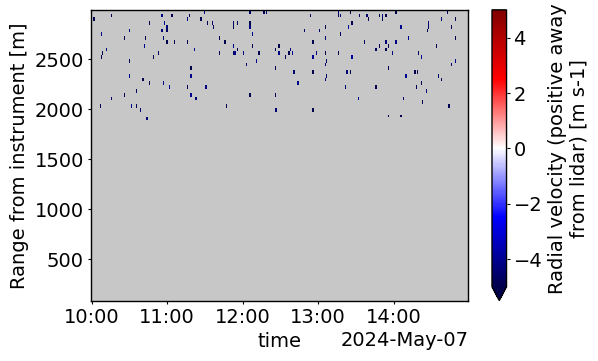

In [124]:
low_v.plot(y='range', cmap='seismic', vmin=-5, vmax=5)

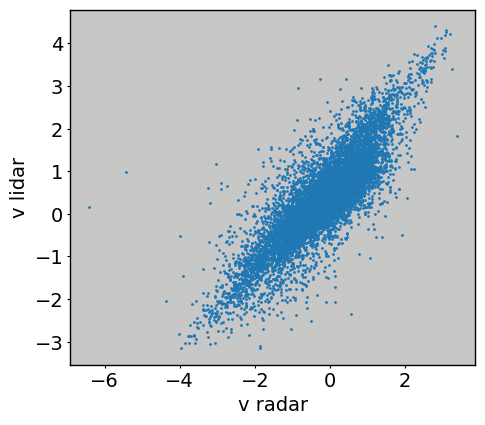

In [182]:
#scatter plot of nb['v'] vs sc['v_raw']
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(nb['v'].values.flatten(), sc['v_raw'].values.flatten(), s=1)
ax.set_xlabel('v radar')
ax.set_ylabel('v lidar')
plt.show()


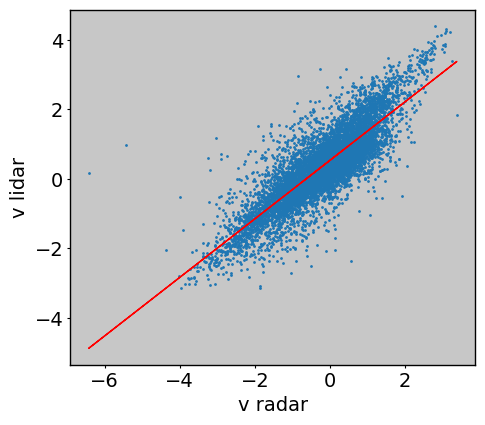

In [188]:
#linear regression using np.polyfit

#remove nans
nb_v = nb['v'].values.flatten()
sc_v = sc['v_raw'].values.flatten()
mask = np.logical_and(np.isfinite(nb_v), np.isfinite(sc_v))
nb_v = nb_v[mask]
sc_v = sc_v[mask]

#fit a line
coeff = np.polyfit(nb_v, sc_v, 1)
fit = np.polyval(coeff, nb_v)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(nb_v, sc_v, s=1)
ax.plot(nb_v, fit, 'r')
ax.set_xlabel('v radar')
ax.set_ylabel('v lidar')
plt.show()




In [191]:
coeff

array([1.        , 0.53477502])